# Inverse kinematics fit from the fly hackathon

In [1]:
from os import path as op
import sys
# sys.path.insert(0, op.abspath('/Users/eabe/Research/MyRepos/BiomechControl/models/fruitfly_v2/'))
sys.path.insert(0, op.abspath('/Users/eabe/Research/Github/flybody'))

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import PIL.ImageDraw
from tqdm import tqdm
import mediapy as media

from dm_control import mujoco
from dm_control import mjcf
from dm_control.mujoco.wrapper.mjbindings import enums
from dm_control.mujoco.wrapper import mjbindings

import sys
sys.path.append('..')
# from dm_control.utils.inverse_kinematics import qpos_from_site_pose
from flybody.inverse_kinematics import qpos_from_site_xpos
from flybody.utils import display_video
from flybody.tasks.task_utils import retract_wings

In [2]:
def transform_frame(frame):
    """Transform a single frame from data to model reference frame."""
    # Rotate around z-axis.
    frame = frame[:, [1, 0, 2]]
    frame[:, 1] *= -1
    # Change units mm to cm.
    frame *= 0.1
    return frame
base_path = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/Archive/fruitfly')
task_path = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/mjpc/tasks/fruitfly/flyqpos2')
# task_path = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/mjpc/tasks/fruitfly/flytrackingqpos')

##### Plotting settings ######
import matplotlib as mpl
mpl.rcParams.update({'font.size':          10,
                     'axes.linewidth':     2,
                     'xtick.major.size':   5,
                     'ytick.major.size':   5,
                     'xtick.major.width':  2,
                     'ytick.major.width':  2,
                     'axes.spines.right':  False,
                     'axes.spines.top':    False,
                     'pdf.fonttype':       42,
                     'svg.fonttype':       'none',
                     'xtick.labelsize':    10,
                     'ytick.labelsize':    10,
                     'figure.facecolor':   'white',
                     'pdf.use14corefonts': True,
                     'font.family':        'sans-serif',
                     'font.sans-serif':    ['Arial']
                    })

# Load a single walking sequence

In [3]:

data_path = base_path / 'combined_wt_berlin_walking_v3.pq'
full_df = pd.read_parquet(data_path, engine='pyarrow')
bout_stats = full_df.groupby(['walking_bout_number','fullfile','Sex'])[['fictrac_delta_rot_lab_y_mms', 'fictrac_delta_rot_lab_z_deg/s']].agg(['mean','min','max','std','count'])
fast = (bout_stats[('fictrac_delta_rot_lab_y_mms','mean')] >= 12) & (bout_stats[('fictrac_delta_rot_lab_y_mms','min')] >= 10)
straight = (bout_stats[('fictrac_delta_rot_lab_z_deg/s','mean')].abs() <= 45) &\
           (bout_stats[('fictrac_delta_rot_lab_z_deg/s','min')] >= -60) &\
           (bout_stats[('fictrac_delta_rot_lab_z_deg/s','max')] <= 60)

#minlen =  bout_stats[('fictrac_delta_rot_lab_z_deg/s','count')] >= 300
# bout_stats[fast & straight].sort_values(('fictrac_delta_rot_lab_y_mms','min')).loc['walking_bout_number']

In [4]:
legs = ['T1_left', 'T1_right', 'T2_left', 'T2_right', 'T3_left', 'T3_right']
joints = ['coxa', 'femur', 'tibia', 'tarsus']
xpos_geoms = ['coxa', 'femur', 'tibia', 'tarsus', 'claw']
joint_names = [f'{joint}_{leg}' for leg in legs for joint in joints]
xpos_names = [f'{joint}_{leg}' for leg in legs for joint in xpos_geoms]
# physics.named.data.framepos[pos_names]
site_names = [f'tracking[{joint_name}]' for joint_name in xpos_names]

legs_data = ['L1', 'R1', 'L2','R2', 'L3','R3']
joints_data = ['A','B','C','D','E']
coords_data = ['_x','_y','_z']
joint_pos_columns = [leg + joint + coord 
                     for leg in legs_data
                     for joint in joints_data 
                     for coord in coords_data]

straight_bouts = bout_stats[fast & straight].index
straight_bout_num = np.array([i[0] for i in straight_bouts],dtype=int)
mean_straight_bout = (full_df[full_df['walking_bout_number'] == 14574][joint_pos_columns].values.reshape(-1,30, 3)).mean(axis=0)
ref_bout = (full_df[full_df['walking_bout_number'] == 14574][joint_pos_columns].values.reshape(-1,30, 3))
bout_dict = {'walking_bout{:02}'.format(n):{} for n in range(len(straight_bout_num))}

for n, bout_num in enumerate(straight_bout_num):
    bout = full_df[full_df['walking_bout_number'] == bout_num]
    bout_dict['walking_bout{:02}'.format(n)]['orig_xpos'] = bout[joint_pos_columns].values.reshape(-1,30, 3)
    bout_dict['walking_bout{:02}'.format(n)]['orig_xpos'] = bout_dict['walking_bout{:02}'.format(n)]['orig_xpos'] + (mean_straight_bout-np.mean(bout_dict['walking_bout{:02}'.format(n)]['orig_xpos'],axis=0))

In [ ]:
bout = full_df[full_df['walking_bout_number'] == straight_bout_num[0]]

# Load the fly model

In [4]:
import pickle
import numpy as np
from pathlib import Path
from typing import Union, Dict
import io_dict_to_hdf5 as ioh5
# stac_data = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/Archive/fruitfly/transform_tethered.p')
stac_path = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/Archive/fruitfly/transform_tethered.h5')
mjpc_path = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/Archive/fruitfly/fruitfly_qpos2_002ms.h5')
dm_ik_path = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/bout_dict_free_DM_reg.h5')
fig_path = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/Figures')
fontsize = 30


In [5]:
# Load data
bout_dict = ioh5.load(dm_ik_path)
stac_data = ioh5.load(stac_path)
mjpc_data = ioh5.load(mjpc_path)

# with open(stac_data, "rb") as file:
#     d = pickle.load(file)
#     qposes = np.array(d["qpos"])
#     kp_data = np.array(d["kp_data"])
#     kp_names = d["kp_names"]
#     offsets = d["offsets"]

qposes_mjpc = mjpc_data['qpos'].T
qposes_stac = stac_data['qposes'][:qposes_mjpc.shape[0],:]
kp_data = stac_data['kp_data'][:qposes_mjpc.shape[0],:]
kp_names = stac_data['kp_names']
offsets = stac_data['offsets']
mod_frames = kp_data.reshape(-1,30,3).copy() #+ offsets

In [21]:
mjpc_data.keys()

dict_keys(['cost_terms', 'cost_total', 'ctrl', 'frames', 'qpos', 'qvel', 'time'])

In [6]:

def add_colorbar(mappable,linewidth=2,location='right',**kwargs):
    ''' modified from https://supy.readthedocs.io/en/2021.3.30/_modules/supy/util/_plot.html'''
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    import matplotlib.pyplot as plt
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes(location, size="5%", pad=0.1)
    cbar = fig.colorbar(mappable, cax=cax, drawedges=False,**kwargs)
    cbar.outline.set_linewidth(linewidth)
    plt.sca(last_axes)
    return cbar
def map_discrete_cbar(cmap,N):
    cmap = plt.get_cmap(cmap,N+1)
    bounds = np.arange(-.5,N+1)
    norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
    return cmap, norm

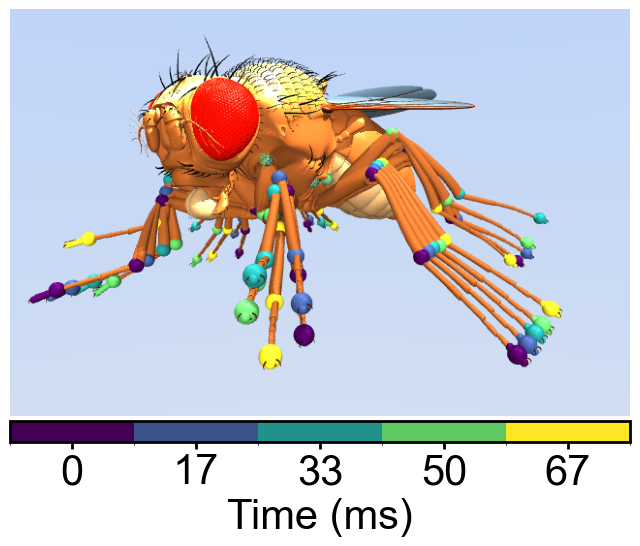

In [220]:
cmap,norm = map_discrete_cbar('viridis',4)
xml_path = task_path / 'task_viz.xml'
# xml_path = task_path.parent / 'fruitfly_force_pair.xml'
# xml_path = task_path.parent / 'fruitfly_force_seq.xml'
# xml_path = task_path.parent / 'fruitfly_freeforce.xml'

mj_model = mujoco.MjModel.from_xml_path(xml_path.as_posix())

mj_data = mujoco.MjData(mj_model)

for n,val in enumerate(['-0','-1','-2','-3','-4','-5']):
    site_names = [mj_model.site(i).name for i in range(mj_model.nsite) if val in mj_model.site(i).name]
    site_id = [mj_model.site(i).id for i in range(mj_model.nsite) if val in mj_model.site(i).name]
    for id in site_id:
        mj_model.site(id).rgba = cmap(n)
        
scene_option = mujoco.wrapper.core.MjvOption()
scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 0]
# scene_option.flags[mujoco.mjtVisFlag.mjVIS_STATIC] = False
# scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = True
mj_data.qpos = np.concatenate([qposes_stac[n] for n in range(0,25,5)])
mujoco.mj_kinematics(mj_model, mj_data)
renderer = mujoco.Renderer(mj_model, height=420, width=640)


# mj_data.mocap_pos = mod_frames[0].copy()
mujoco.mj_forward(mj_model, mj_data)

renderer.update_scene(mj_data, camera='hero', scene_option=scene_option)
pixels = renderer.render()
from mpl_toolkits.axes_grid1 import make_axes_locatable
fig,axs = plt.subplots(1,1,figsize=(8,6))
ax = axs
im1 = ax.imshow(pixels)
cbar = ax.axis('off')
# cbar = add_colorbar(im1,linewidth=2,location='bottom',cmap=cmap)
divider = make_axes_locatable(ax)
cax = divider.append_axes('bottom', size='5%', pad=0.05)
# cbar = fig.colorbar(im1, cax=cax, orientation='horizontal',cmap=cmap,norm=norm)
# cbar = plt.colorbar( cax=cax, orientation='horizontal',cmap=cmap, norm=norm)
# cbar.set_label('Time (ms)')

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
             cax=cax, orientation='horizontal',ticks=np.arange(0,5))
# cbar.set_ticks(np.arange(0,5))
cbar.ax.set_xticklabels((np.round(np.arange(0,25,5)*(1/300),3)*1000).astype(int),fontsize=fontsize)
cbar.set_label('Time (ms)',fontsize=fontsize)
# fig.savefig('example_mocap_seq.svg',format='svg',dpi=300,transparent=True)
# PIL.Image.fromarray(pixels)
# im.save('example_mocap.png',format='png')

In [271]:
mocap_names = [mj_model.site(i).name for i in range(mj_model.nsite) if 'mocap' in mj_model.site(i).name]
mocap_id = [mj_model.site(i).id for i in range(mj_model.nsite) if 'mocap' in mj_model.site(i).name]

['mocap[coxa_T1_left]',
 'mocap[femur_T1_left]',
 'mocap[tibia_T1_left]',
 'mocap[tarsus_T1_left]',
 'mocap[claw_T1_left]',
 'mocap[coxa_T1_right]',
 'mocap[femur_T1_right]',
 'mocap[tibia_T1_right]',
 'mocap[tarsus_T1_right]',
 'mocap[claw_T1_right]',
 'mocap[coxa_T2_left]',
 'mocap[femur_T2_left]',
 'mocap[tibia_T2_left]',
 'mocap[tarsus_T2_left]',
 'mocap[claw_T2_left]',
 'mocap[coxa_T2_right]',
 'mocap[femur_T2_right]',
 'mocap[tibia_T2_right]',
 'mocap[tarsus_T2_right]',
 'mocap[claw_T2_right]',
 'mocap[coxa_T3_left]',
 'mocap[femur_T3_left]',
 'mocap[tibia_T3_left]',
 'mocap[tarsus_T3_left]',
 'mocap[claw_T3_left]',
 'mocap[coxa_T3_right]',
 'mocap[femur_T3_right]',
 'mocap[tibia_T3_right]',
 'mocap[tarsus_T3_right]',
 'mocap[claw_T3_right]']

In [16]:
xml_path = task_path / 'task_viz.xml'
# xml_path = task_path.parent / 'fruitfly_force_pair.xml'
# xml_path = task_path.parent / 'fruitfly_force_seq.xml'
# xml_path = task_path.parent / 'fruitfly_freeforce.xml'

mj_model = mujoco.MjModel.from_xml_path(xml_path.as_posix())

mj_data = mujoco.MjData(mj_model)

mocap_names = [mj_model.site(i).name for i in range(mj_model.nsite) if 'mocap' in mj_model.site(i).name]
mocap_id = [mj_model.site(i).id for i in range(mj_model.nsite) if 'mocap' in mj_model.site(i).name]
# for id in mocap_id:
#     mj_model.site(id).rgba = [0,1,0,1]
site_names = [mj_model.site(i).name for i in range(mj_model.nsite) if '-1' in mj_model.site(i).name]
site_id = [mj_model.site(i).id for i in range(mj_model.nsite) if '-1' in mj_model.site(i).name]
for id in site_id:
    mj_model.site(id).rgba = [1,0,0,1]

# geom_names = [mj_model.geom(i).name for i in range(mj_model.ngeom) if 'T3_left' in mj_model.geom(i).name]
# geom_ids = [mj_model.geom(i).id for i in range(mj_model.ngeom) if 'T3_left' in mj_model.geom(i).name]

# for id in geom_ids[5:]:
#     mj_model.geom(id).group = 4

camera_id = 0

scene_option = mujoco.MjvOption()
scene_option.sitegroup[:] = [1, 1, 1, 0, 1, 0]
# scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_JOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_ACTUATOR] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_LIGHT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONVEXHULL] = True
scene_option.flags[mujoco.mjtRndFlag.mjRND_SHADOW] = False
scene_option.flags[mujoco.mjtRndFlag.mjRND_REFLECTION] = False
scene_option.flags[mujoco.mjtRndFlag.mjRND_SKYBOX] = False
scene_option.flags[mujoco.mjtRndFlag.mjRND_FOG] = False
# scene_option.flags[mujoco.mjtVisFlag.mjVIS_STATIC] = False

# mj_data.qpos = np.concatenate([qposes_stac[n] for n in range(0,2)])
# mj_data.qpos = qposes_stac[0]
mujoco.mj_kinematics(mj_model, mj_data)
renderer = mujoco.Renderer(mj_model, height=420, width=550)


# mj_data.mocap_pos = mod_frames[0].copy()
mujoco.mj_forward(mj_model, mj_data)

renderer.update_scene(mj_data, camera=camera_id, scene_option=scene_option)
pixels = renderer.render()
PIL.Image.fromarray(pixels)
# im = PIL.Image.fromarray(pixels)
# im.save(fig_path/'init_camera{}.png'.format(camera_id),format='png')

In [8]:
# qpos_frames = qposes_mjpc.T.copy()
camera_id = 1 # Side view.

# Show all sites.
scene_option = mujoco.wrapper.core.MjvOption()
scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 0]

scene_option.flags[enums.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True

video_frames_STAC = []
for t,(qpos1, qpos2) in  tqdm(enumerate(zip(qposes_stac[:601],qposes_mjpc[:601],))):
    mj_data.qpos = np.append(qpos1, qpos2)
    # mj_data.mocap_pos = mod_frames[t].copy()
    mujoco.mj_forward(mj_model, mj_data)
    renderer.update_scene(mj_data, camera=camera_id,scene_option=scene_option)
    pixels = renderer.render()
    video_frames_STAC.append(pixels)
    

601it [00:24, 24.56it/s]


In [9]:
media.show_video(video_frames_STAC, fps=50)
media.write_video(fig_path /'superimposed_camera{}.mp4'.format(camera_id),video_frames_STAC, fps=50)

This browser does not support the video tag.


In [ ]:
# Generate video of fitted poses.
qpos_frames = qposes_stac.copy()
# qpos_frames = qposes_mjpc.T.copy()
mod_frames = kp_data.reshape(-1,30,3).copy() #+ offsets
camera_id = 1 # Side view.

# Show all sites.
scene_option = mujoco.wrapper.core.MjvOption()
scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 0]

# scene_option.flags[enums.mjtVisFlag.mjVIS_CONTACTPOINT] = True
# scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True


#retract_wings(physics)

video_frames_STAC = []
for t,q in tqdm(enumerate(qpos_frames)):
    # with mujoco.reset():
    mj_data.qpos = q
    mj_data.mocap_pos = mod_frames[t].copy()
    mujoco.mj_forward(mj_model, mj_data)
    renderer.update_scene(mj_data, camera=camera_id,scene_option=scene_option)
    pixels = renderer.render()
    video_frames_STAC.append(pixels)
    
# Generate video of fitted poses.
# qpos_frames = qposes[:601,:].copy()
qpos_frames = qposes_mjpc.copy()
mod_frames = kp_data.reshape(-1,30,3).copy() #+ offsets
camera_id = 1 # Side view.

# Show all sites.
scene_option = mujoco.wrapper.core.MjvOption()
scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 0]
# scene_option.flags[enums.mjtVisFlag.mjVIS_CONTACTPOINT] = True
# scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True


#retract_wings(physics)

video_frames_MJPC = []
for t,q in tqdm(enumerate(qpos_frames)):
    # with mujoco.reset():
    mj_data.qpos = q
    mj_data.mocap_pos = mod_frames[t].copy()
    mujoco.mj_forward(mj_model, mj_data)
    renderer.update_scene(mj_data, camera=camera_id,scene_option=scene_option)
    pixels = renderer.render()
    video_frames_MJPC.append(pixels)
video_frames_MJPC = np.stack(video_frames_MJPC)
video_frames_STAC = np.stack(video_frames_STAC)

In [21]:
video_frames_MJPC = np.stack(video_frames_MJPC)
video_frames_STAC = np.stack(video_frames_STAC)

In [ ]:
combined_frames = np.concatenate([video_frames_STAC,video_frames_MJPC],axis=2)
media.show_video(combined_frames, fps=50,)
media.write_video('combined_examplevid.mp4',combined_frames, fps=50,)

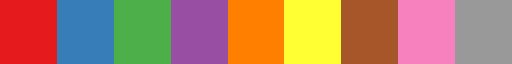

In [259]:
cmap = plt.get_cmap('Set1', 9)
cmap

In [253]:
joint_names = [mj_model.joint(i).name for i in range(mj_model.njnt)]
# joint_names = [mj_model.joint(i).name for i in range(mj_model.njnt) if '-0' in mj_model.joint(i).name]
joint_names = [joint_names.replace('-0','').replace('_left','L').replace('_right','R').replace('_',' ').replace('flexion','fl').replace('twist','tw') for joint_names in joint_names]
qposes_stac = qposes_stac[:qposes_mjpc.shape[0],:]

In [254]:
mean_error = np.rad2deg(np.mean(np.abs(qposes_stac[:qposes_mjpc.shape[0],:] - qposes_mjpc),axis=0))
std_error = np.std(np.rad2deg(np.abs(qposes_stac[:qposes_mjpc.shape[0],:] - qposes_mjpc)),axis=0)

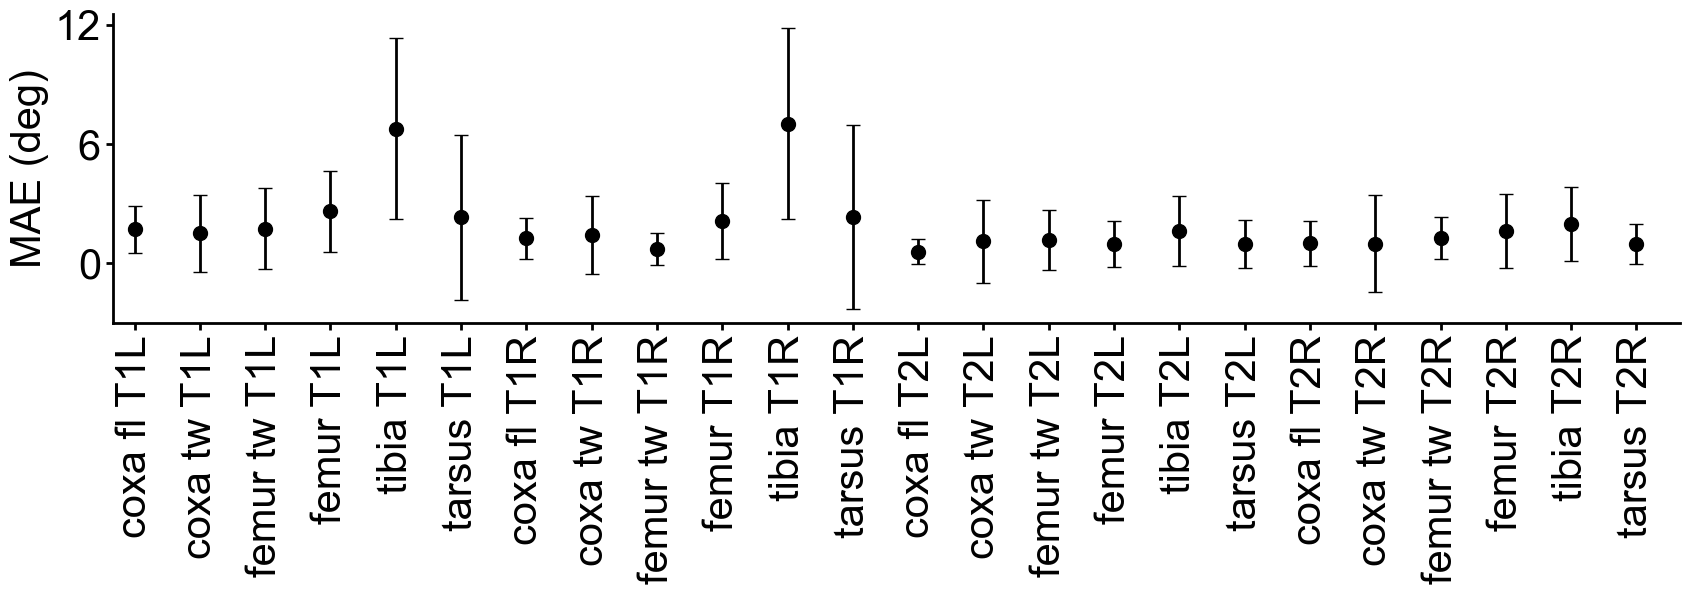

In [261]:
fig, axs = plt.subplots(1,1,figsize=(17, 6))
ax = axs
xs = 1.5*np.arange(mean_error.shape[0])
ax.errorbar(xs,mean_error,yerr=std_error,fmt='o',c='k',markersize=10,elinewidth=2,capsize=5)
ax.set_xticks(xs)
ax.set_xticklabels(joint_names,rotation=90, fontsize=fontsize)
ax.set_ylabel('MAE (deg)', fontsize=fontsize)
ax.set_yticks([0,6,12])
ax.tick_params(axis='x', labelsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize)
ax.set_xlim(-.5,mean_error.shape[0]-.5)
plt.tight_layout()
plt.show()
fig.savefig(fig_path/'mean_abs_error.svg',bbox_inches='tight',dpi=300,transparent=True)

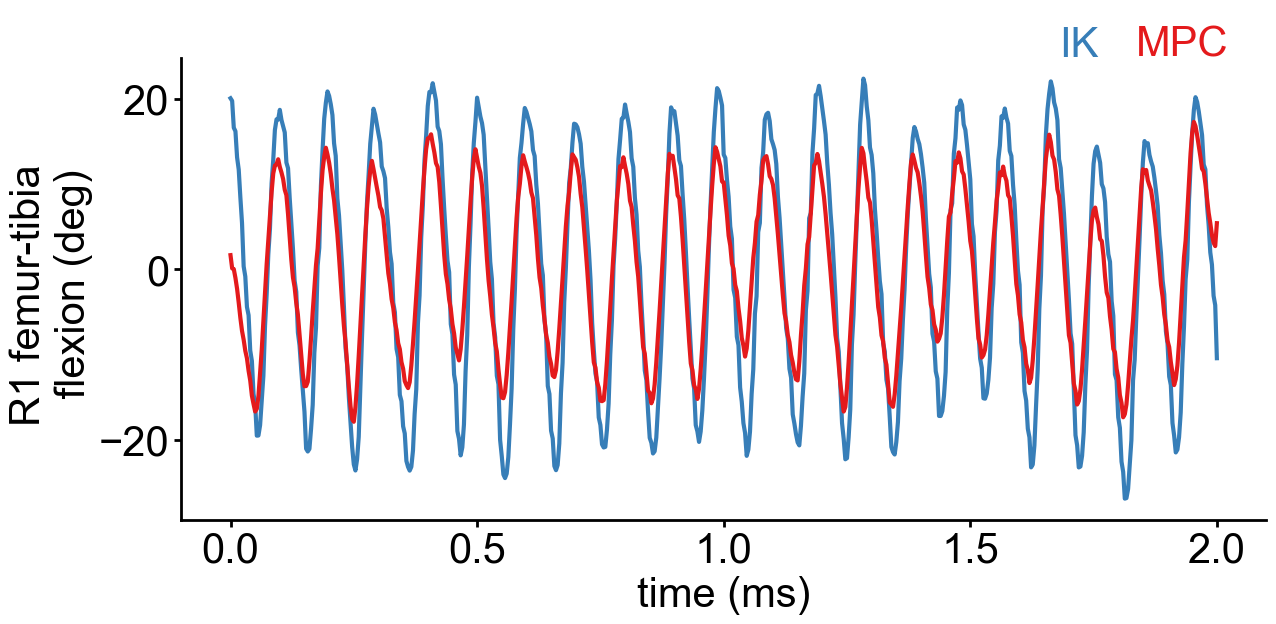

In [262]:
fig, axs = plt.subplots(1,1 ,figsize=(14., 6),sharex=True)
sample_rate = 1/300
t = 0
dt = 601
# ax = axs[0]
# ax.plot(sample_rate*np.arange(0,dt),np.rad2deg(qposes_stac[t:t+dt,6] - np.mean(qposes_stac[t:t+dt,6],axis=0)),c=cmap(1), lw=3, label='IK')
# ax.plot(sample_rate*np.arange(0,dt),np.rad2deg(qposes_mjpc[t:t+dt,6] - np.mean(qposes_mjpc[t:t+dt,6],axis=0)),c=cmap(0), lw=3, label='MPC')
# # ax.set_xlabel('time (ms)', fontsize=fontsize)
# # ax.set_xticks([0, 0.5, 1,1.5,2])
# # ax.tick_params(axis='x', labelsize=fontsize)
# ax.set_yticks([-10,0,10])
# # ax.set_ylim(-10,10)
# ax.tick_params(axis='y', labelsize=fontsize)
# ax.set_ylabel('R1 body-coxa \n flexion (deg)', fontsize=fontsize)
# ax.legend(frameon=False,fontsize=fontsize,loc='upper right',bbox_to_anchor=(1,1.15),labelcolor='linecolor',handlelength=0,handleheight=0,ncols=2,columnspacing=.1)

ax = axs
ax.plot(sample_rate*np.arange(0,dt),np.rad2deg(qposes_stac[t:t+dt,10] - np.mean(qposes_stac[t:t+dt,10],axis=0)),c=cmap(1), lw=3, label='IK')
ax.plot(sample_rate*np.arange(0,dt),np.rad2deg(qposes_mjpc[t:t+dt,10] - np.mean(qposes_mjpc[t:t+dt,10],axis=0)),c=cmap(0), lw=3, label='MPC')
ax.set_xlabel('time (ms)', fontsize=fontsize)
ax.set_xticks([0, 0.5, 1,1.5,2])
ax.tick_params(axis='x', labelsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize)
ax.set_ylabel('R1 femur-tibia \n flexion (deg)', fontsize=fontsize)
ax.legend(frameon=False,fontsize=fontsize,loc='upper right',bbox_to_anchor=(1,1.15),labelcolor='linecolor',handlelength=0,handleheight=0,ncols=2,columnspacing=.1)

fig.savefig(fig_path/'R1_femur_tibia_flexion.svg',bbox_inches='tight',dpi=300,transparent=True)

In [13]:
ctrl_mjpc = mjpc_data['ctrl'].T

Text(0, 0.5, 'ctrl femur-tibia \n flexion (deg)')

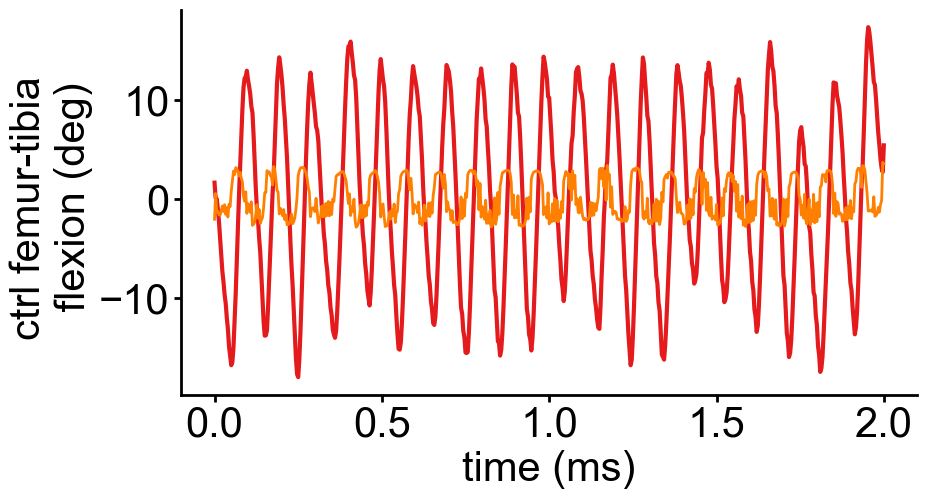

In [48]:
fig, axs = plt.subplots(1,1 ,figsize=(9.5, 5))
ax = axs
sample_rate = 1/300
t = 0
dt = 601
ax.plot(sample_rate*np.arange(0,dt),np.rad2deg(qposes_mjpc[t:t+dt,10] - np.mean(qposes_mjpc[t:t+dt,10],axis=0)),c=cmap(0), lw=3)
ax.plot(sample_rate*np.arange(0,dt),ctrl_mjpc[t:t+dt,10] ,c=cmap(4), lw=2)
ax.set_xlabel('time (ms)', fontsize=fontsize)
ax.set_xticks([0, 0.5, 1,1.5,2])
ax.tick_params(axis='x', labelsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize)
ax.set_ylabel('ctrl femur-tibia \n flexion (deg)', fontsize=fontsize)
# fig.savefig(fig_path/'R1_femur_tibia_flexion.svg',bbox_inches='tight',dpi=300,transparent=True)

In [ ]:
# xml_path = task_path / 'task.xml'
# xml_path = '/Users/eabe/Research/MyRepos/mujoco_mpc/mjpc/tasks/fruitfly/flytrackingqpos/task.xml'
mjcf_model = mjcf.from_path(xml_path)

# Visualize fly as loaded.
physics = mjcf.Physics.from_mjcf_model(mjcf_model)
_ = physics.reset()
pixels = physics.render(camera_id=1, width=640, height=480)
PIL.Image.fromarray(pixels)

In [ ]:
# Generate video of fitted poses.
qpos_frames = qposes[:601,:].copy()
mod_frames = kp_data.reshape(-1,30,3).copy() + offsets
camera_id = 1 # Side view.

# Show all sites.
scene_option = mujoco.wrapper.core.MjvOption()
scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 0]
scene_option.flags[enums.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True


#retract_wings(physics)

video_frames_STAC = []
for t,q in tqdm(enumerate(qpos_frames)):
    with physics.reset_context():
        physics.data.qpos = qpos_frames[t].copy()
        physics.data.mocap_pos = mod_frames[t].copy()
        physics.step()
    pixels = physics.render(camera_id=camera_id, width=640, height=480, scene_option=scene_option)
    video_frames_STAC.append(pixels)

In [13]:
# stac_dict = {'qpos':np.array(qposes), 'kp_data':np.array(kp_data), 'offsets':np.array(offsets)}
# ioh5.save(stac_data.parent/'stac_dict', stac_dict)

### Save xml key frames

In [ ]:
import pickle
import numpy as np
from pathlib import Path
from dm_control import mjcf

stac_data = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/Archive/fruitfly/transform.p')
# xml_path = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/mjpc/tasks/fruitfly/flytrackingqpos/task.xml')
# xml_path = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/mjpc/tasks/fruitfly/fruitfly_force_ball.xml')

with open(stac_data, "rb") as file:
    d = pickle.load(file)
    qposes = np.array(d["qpos"])
    kp_data = np.array(d["kp_data"])
    kp_names = d["kp_names"]
    offsets = d["offsets"]
mjcf_model = mjcf.from_path(xml_path)
physics = mjcf.Physics.from_mjcf_model(mjcf_model)
joint_ranges = physics.named.model.jnt_range
joints_to_manipulate = [j.name for j in mjcf_model.find_all('joint')]

for n,(jointrange,minjnt,maxjnt) in enumerate(zip(joint_ranges, np.min(qposes[:,6:],axis=0),np.max(qposes[:,6:],axis=0))):
    print('{},{}, xml_range: {}, min:{:.04f}, max:{:.04f}, Valid: {}'.format(n,joints_to_manipulate[n],jointrange,minjnt,maxjnt, (minjnt>=jointrange[0])&(maxjnt<=jointrange[1])))

In [12]:
qpos_frames = qposes.copy()
qvel_frames = np.diff(qpos_frames, axis=0, prepend=qpos_frames[0:1,:])
mod_frames = kp_data.reshape(-1,30,3).copy()# + offsets
# mod_frames = np.concatenate([bout_dict[key]['inv_xpos'] for key in bout_dict.keys()],axis=0)# + offsets


In [ ]:
t = 0
walking_bout_n = 1
root = mjcf.RootElement()
root.keyframe.add('key', name=f'Stac_{walking_bout_n}_1', mpos=mod_frames[0].flatten(),qpos=qpos_frames[0].flatten())
for n in range(2,qpos_frames.shape[0]):
    root.keyframe.add('key', name=f'Stac_{walking_bout_n}_{n}', mpos=mod_frames[n].flatten(),qpos=qpos_frames[n].flatten())
    
# save xml file
# root = root.default.remove()
keyframe_path = task_path / 'keyframes/'
filename = f'Fly_qpos{walking_bout_n}_stac.xml'
mjcf.export_with_assets(root, keyframe_path,filename)
keyframe_path/filename

# TG angles

## align TG and flybody

In [ ]:
from flybody.quaternions import *

In [ ]:
np.rad2deg(vec_world_to_local(mj_model.joint(22).axis, mj_model.body(22).quat))

In [ ]:
# body_names = [mj_model.body(i).name for i in range(mj_model.nbody)]
# mj_model.joint(4), 
# mj_model.body(22).iquat
mj_model.joint(22)

In [ ]:
mj_model.n

In [ ]:
mj_model.site(0)

<_MjModelSiteViews
  bodyid: array([1], dtype=int32)
  group: array([3], dtype=int32)
  id: 0
  matid: array([-1], dtype=int32)
  name: 'thorax-0'
  pos: array([0., 0., 0.])
  quat: array([1., 0., 0., 0.])
  rgba: array([0.5, 0.5, 0.5, 1. ], dtype=float32)
  sameframe: array([1], dtype=uint8)
  size: array([0.01 , 0.005, 0.005])
  type: array([2], dtype=int32)
  user: array([], dtype=float64)
>

In [5]:
tg_angles = np.load('/Users/eabe/Research/MyRepos/mujoco_mpc/TG_angles.npy')

In [ ]:
quat = euler2quat([0,2.42011515, -2.75248032])
quat

In [ ]:
# xml_path = task_path / 'task.xml'
# xml_path = '/Users/eabe/Research/MyRepos/mujoco_mpc/mjpc/tasks/fruitfly/flytrackingqpos/task.xml'
mjcf_model = mjcf.from_path(xml_path)

# Visualize fly as loaded.
physics = mjcf.Physics.from_mjcf_model(mjcf_model)
_ = physics.reset()
pixels = physics.render(camera_id=1, width=640, height=480)
PIL.Image.fromarray(pixels)

In [14]:
physics.data.qpos = np.deg2rad(tg_angles[0]).copy()

In [ ]:
# Generate video of fitted poses.
qpos_frames = tg_angles.copy()
# mod_frames = kp_data.reshape(-1,30,3).copy() + offsets
camera_id = 3 # Side view.

# Show all sites.
scene_option = mujoco.wrapper.core.MjvOption()
scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 0]
# scene_option.flags[enums.mjtVisFlag.mjVIS_CONTACTPOINT] = True
# scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True


#retract_wings(physics)

video_frames_STAC = []
for t,q in tqdm(enumerate(qpos_frames)):
    with physics.reset_context():
        physics.data.qpos = tg_angles[t].copy()#qpos_frames[t].copy()
        # physics.data.mocap_pos = mod_frames[t].copy()
    pixels = physics.render(camera_id=camera_id, width=640, height=480, scene_option=scene_option)
    video_frames_STAC.append(pixels)

In [ ]:
display_video(video_frames_STAC, framerate=50)

In [31]:
%matplotlib inline

In [ ]:

plt.plot(tg_angles)
plt.show()